In [1]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from datetime import datetime
import numpy as np
from torch.utils.data import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F
from collections import Counter
import json
from itertools import product

In [2]:
torch.manual_seed(42)
torch.set_default_dtype(torch.double)

In [3]:
device = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cpu.


In [4]:
CLASS_COLOURS = ['skyblue', 'pink']

In [5]:
def show_img(img, label) -> None:
    img = img.squeeze().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

/home/henrik/school/inf265_projects/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


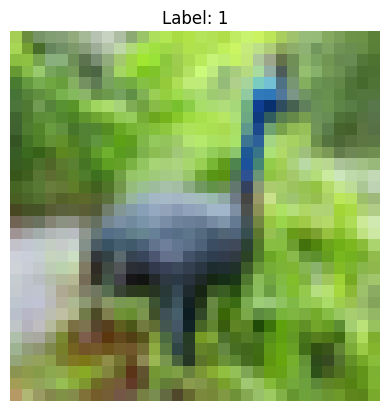

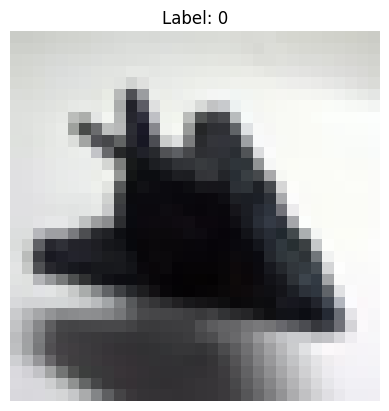

In [6]:
class CIFAR2(Dataset):
    def __init__(self, data_path: Path):
        self.data_path = data_path
        self.data, self.targets = self.__loaddata__()

        self.transformer = transforms.Compose([
            transforms.ToTensor(),
        ])
    
    def __loaddata__(self):
        data = datasets.CIFAR10(
            root=str(self.data_path),
            transform=None,
            download=True
        )
        targets = np.array(data.targets)
        indices = (targets == 0) | (targets == 2) # plane, bird

        images, targets = data.data[indices], targets[indices]

        # resample 0 is ok, 2 -> 1
        targets = [1 if t == 2 else t for t in targets]

        return images, targets

    def __getitem__(self, idx) -> tuple[torch.Tensor, int]:
        img, target = self.data[idx], self.targets[idx]        
        return self.transformer(img), target

    def __len__(self):
        return len(self.data)

cifar = CIFAR2("data/")
img, label = cifar[0]
show_img(img, label) # bird = 1
img, label = cifar[4]
show_img(img, label) # plane = 0

In [7]:
class Preprocessor():
    """wip"""
    def __init__(self):
        ...
        self.transformer = transforms.Compose([
            # TODO: is this the correct normalization for CIFAR10?
            transforms.Normalize((0.4915, 0.4823, 0.4468),
                                 (0.2470, 0.2435, 0.2616))
            
        ])

In [8]:
def load_cifar(train_val_split=0.9, data_path='data/', preprocessor=None):
    cifar2 = CIFAR2(Path(data_path))

    train_size = int(len(cifar2) * train_val_split)
    val_test_size = len(cifar2) - train_size

    cifar_generator = torch.Generator().manual_seed(42)
    train, val_test = random_split(cifar2, lengths=[train_size, val_test_size], generator=cifar_generator)
    
    test_val_split = 0.5 # 0.05, 0.05
    val_size = int(len(val_test) * test_val_split)
    test_size = len(val_test) - val_size
    
    val, test = random_split(val_test, lengths=[val_size, test_size], generator=cifar_generator)    

    batch_size = 32
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

train_loader,val_loader,test_loader = load_cifar()

def binary_to_label(targets):
    all_targets = ["plane" if t == 0 else t for t in targets]
    return ["bird" if t == 1 else t for t in all_targets ]

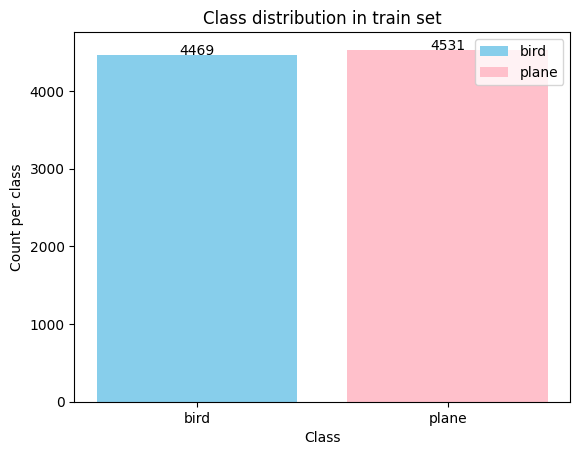

In [9]:
all_targets = torch.cat([label for _, label in train_loader]).tolist()
all_targets = binary_to_label(all_targets)

counts = Counter(all_targets)
plt.bar(list(counts.keys()), list(counts.values()), label=counts.keys(), color = CLASS_COLOURS)
plt.xlabel("Class")
plt.ylabel("Count per class")
plt.title("Class distribution in train set")
for x, y in counts.items():
    plt.text(x, y, f"{y}", ha='center')
plt.legend()
plt.show()

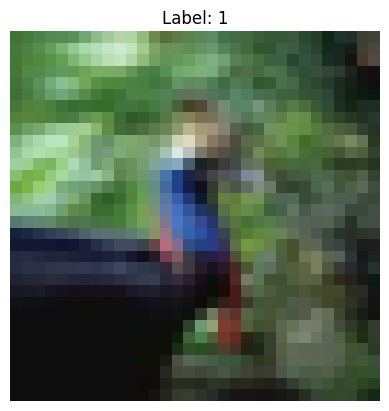

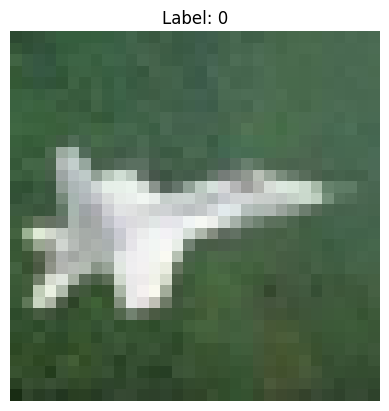

In [10]:
# TODO: variance in pixel colours
img, label = cifar[15]
show_img(img, label) # bird = 1
img, label = cifar[16]
show_img(img, label) # plane = 0


In [11]:
def train(n_epochs, optimizer, model, loss_fn, train_loader: DataLoader, validation_loader: DataLoader):
    
    n_batch_train = len(train_loader)
    n_batch_val = len(validation_loader)
    losses_train, losses_val = [], []
    model.train() # set to train mode
    optimizer.zero_grad(set_to_none=True)
    
    for epoch in range(1, n_epochs + 1):
        loss_train, loss_val = 0.0, 0.0
        for imgs, labels in train_loader:

            imgs = imgs.to(device=device) 
            labels = labels.to(device=device)

            outputs = model(imgs)
            
            loss = loss_fn(outputs, labels)
            loss.backward()
            
            optimizer.step()
            optimizer.zero_grad()

            loss_train += loss.item()

        model.eval() # observe model performance
        with torch.no_grad():
            for val_imgs, val_labels in validation_loader:

                imgs_val = val_imgs.to(device=device) 
                val_labels = val_labels.to(device=device)
                val_outputs = model(imgs_val)
                val_loss = loss_fn(val_outputs, val_labels)
                loss_val += val_loss.item() 

        # swap back to train mode
        model.train()
            
        losses_train.append(loss_train / n_batch_train)
        losses_val.append(loss_val / n_batch_val)

        if epoch == 1 or epoch % 10 == 0: # TODO add validation loss
            print('{}  |  Epoch {}  |  Training loss {:.3f}'.format(
                datetime.now().time(), epoch, loss_train / n_batch_train))
    return losses_train, losses_val

In [12]:
class MyMLPBaseLine(nn.Module):
    """
    inp layer: 3072 - 512 relu
    hid layer: 512 - 128 relu
    hid layer: 128 - 32 relu
    out layer: 32 - 2 no activation function
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, 2)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)  # final layer
        return out
    
    def name(self):
        return "MLPBaseline"

In [13]:
# a. Increase the size of a hidden layer (wider)
class MyMLPWide(nn.Module):
    """
    inp layer: 3072 - 512 relu
    hid layer: 512 - 128 relu
    hid layer: 128 - 32 relu
    out layer: 32 - 2 no activation function
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256) # increased to 256 from 128
        self.fc3 = nn.Linear(256, 32) # increased to 256 from 128
        self.fc4 = nn.Linear(32, 2)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)  # final layer
        return out

    def name(self):
        return "MLPWide"

In [14]:
# b. Increasing the model depth by adding one or more hidden layers (deeper)
class MyMLPDeep(nn.Module):
    """
    inp layer: 3072 - 512 relu
    hid layer: 512 - 128 relu
    hid layer: 128 - 64 relu
    hid layer: 64 - 32 relu
    out layer: 32 - 2 no activation function
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 64) # additional layer
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 2)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = F.relu(self.fc3(out))
        out = F.relu(self.fc4(out))
        out = self.fc5(out)
        return out

    def name(self):
        return "MLPDeep"

In [15]:
class MyMLPDropout(nn.Module):
    """
    inp layer: 3072 - 512 relu (0.2 dropout)
    hid layer: 512 - 128 relu (0.2 dropout)
    hid layer: 128 - 32 relu (0.2 dropout)
    out layer: 32 - 2 no activation function (no dropout)
    """
    def __init__(self, dropout_rate: float):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, 2)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = torch.flatten(x, 1)
        out = self.dropout(F.relu(self.fc1(out)))
        out = self.dropout(F.relu(self.fc2(out)))
        out = self.dropout(F.relu(self.fc3(out)))
        out = self.fc4(out)
        return out
    
    def name(self):
        return "MLPDropout"

Lets run a quick check to see that everything is in order

In [16]:
model_baseline = MyMLPBaseLine().to(device)

In [17]:
optimizer = optim.SGD(model_baseline.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

train_losses, validation_losses = train(
    n_epochs = 30,
    optimizer = optimizer,
    model = model_baseline,
    loss_fn = loss_fn,
    train_loader = train_loader,
    validation_loader=val_loader,
)

13:43:23.280733  |  Epoch 1  |  Training loss 0.664
13:43:36.399338  |  Epoch 10  |  Training loss 0.452
13:43:50.764979  |  Epoch 20  |  Training loss 0.382
13:44:05.419824  |  Epoch 30  |  Training loss 0.333


In [18]:
def plot_train_val_losses(train_losses, val_losses, params: dict = None, ax = None, title = None):

    epoch_investigate_points =  [5,15,30]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))

    ax.plot(train_losses, label="train loss")
    ax.plot(val_losses, label="val loss")

    if title:
        ax.set_title(title)

    y_max = max(max(train_losses), max(val_losses))
    y_offset = 0.05 * y_max  # small offset above curves

    for epoch in epoch_investigate_points:
        if epoch-1 < len(train_losses):  # check bounds
            train_val = train_losses[epoch-1]
            val_val = val_losses[epoch-1]

            # vertical line
            ax.axvline(x=epoch-1, color='gray', linestyle='--', alpha=0.5)

            # text above the curves
            ax.text(epoch-1, y_max + y_offset, f"Val loss: {val_val:.3f}", color='orange',
                    fontsize=9, ha='center', va='bottom')
            ax.text(epoch-1, y_max + 2*y_offset, f"Train loss: {train_val:.3f}", color='blue',
                    fontsize=9, ha='center', va='bottom')


    # https://matplotlib.org/stable/gallery/text_labels_and_annotations/placing_text_boxes.html
    if params: 
        param_text = "\n".join([f"{key} : {value}" for key, value in params.items()])
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(
            x = 0.05,
            y = 0.05,
            s = param_text,
            transform=ax.transAxes,
            verticalalignment='bottom',
            bbox=props
        )
            
    ax.legend()
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    return ax

<Axes: xlabel='epoch', ylabel='loss'>

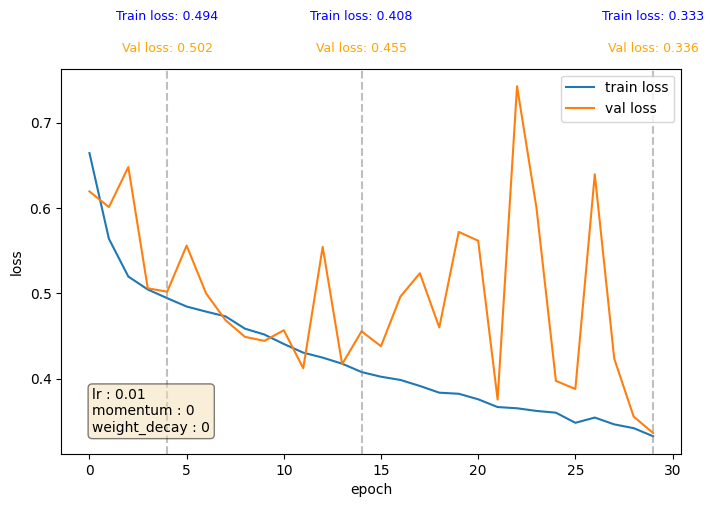

In [19]:
baseline_plot = plot_train_val_losses(
                      train_losses=train_losses, 
                      val_losses=validation_losses, 
                      params={"lr":1e-2, "momentum":0, "weight_decay":0}, 
                    )
baseline_plot

Looks good, let's define hyperparameters

In [20]:
# params to try, this took too long!
# learning_rate_ls = [1e-3, 5e-3, 1e-2]
# momentum_ls = [0.0, 0.5, 0.9]
# weight_decay_ls = [0.0, 1e-4, 1e-3, 1e-2]

learning_rate_ls = [1e-3, 1e-2]
momentum_ls = [0.5, 0.9]
weight_decay_ls = [1e-4, 1e-2]

# only for dropout model
dropout_rate_ls = [0.2, 0.4] # wanted to try 0.8 to see the effect

MAX_EPOCHS  = 30

models = [
    MyMLPBaseLine,
    # MyMLPDeep,
    # MyMLPWide,
    # MyMLPDropout
]

In [ ]:
all_model_outcomes = {} # dict{ model_name : list[params, train_losses, val_losses] }

for model_class in models:

    params_and_losses: list[tuple[dict, list, list]] = [] # list[params, train_losses, val_losses]

    if model_class == MyMLPDropout:
        perms = product(
            learning_rate_ls, momentum_ls, weight_decay_ls, dropout_rate_ls
        )
        model_count = len(learning_rate_ls) * len(momentum_ls) * len(weight_decay_ls), len(dropout_rate_ls)
    else:
        perms = product(
            learning_rate_ls, momentum_ls, weight_decay_ls
        )
        model_count = len(learning_rate_ls) * len(momentum_ls) * len(weight_decay_ls)

    for index, hyperparams in enumerate(perms):
        if model_class == MyMLPDropout:
            learning_rate, momentum, weight_decay, dropout_rate = hyperparams
            model = model_class(dropout_rate=dropout_rate).to(device)
        else:
            learning_rate, momentum, weight_decay = hyperparams
            model = model_class().to(device)

        optimizer = optim.SGD(
                model.parameters(),
                lr=learning_rate,
                momentum=momentum,
                weight_decay=weight_decay,
            )

        loss_fn = nn.CrossEntropyLoss()

        params = {
            "model": model.name(),
            "learning_rate": learning_rate,
            "momentum": momentum,
            "weight_decay": weight_decay,
        }
        if model_class == MyMLPDropout:
            params["dropout_rate"] = dropout_rate

        train_losses, validation_losses = train(
            n_epochs = MAX_EPOCHS,
            optimizer = optimizer,
            model = model,
            loss_fn = loss_fn,
            train_loader = train_loader,
            validation_loader=val_loader,
        )
        print(f"Trained {index} of {model_count} model permuations")

        params_and_losses.append((params, train_losses, validation_losses))

    print(f"Finished training {model.name()}")
    all_model_outcomes[model.name()] = params_and_losses

all_model_outcomes.keys()


13:44:07.856479  |  Epoch 1  |  Training loss 0.689
13:44:29.377885  |  Epoch 10  |  Training loss 0.536
13:44:52.295393  |  Epoch 20  |  Training loss 0.486
13:45:13.873564  |  Epoch 30  |  Training loss 0.447
Trained 0 of 6 model permuations
13:45:16.112256  |  Epoch 1  |  Training loss 0.685
13:45:35.935360  |  Epoch 10  |  Training loss 0.526
13:45:58.298630  |  Epoch 20  |  Training loss 0.485
13:46:20.664189  |  Epoch 30  |  Training loss 0.460
Trained 1 of 6 model permuations
13:46:22.936569  |  Epoch 1  |  Training loss 0.666
13:46:42.927602  |  Epoch 10  |  Training loss 0.432
13:47:05.392641  |  Epoch 20  |  Training loss 0.352
13:47:27.393715  |  Epoch 30  |  Training loss 0.318
Trained 2 of 6 model permuations
13:47:29.566516  |  Epoch 1  |  Training loss 0.669
13:47:49.241389  |  Epoch 10  |  Training loss 0.443
13:48:11.878599  |  Epoch 20  |  Training loss 0.392
13:48:34.564369  |  Epoch 30  |  Training loss 0.346
Trained 3 of 6 model permuations
13:48:36.830178  |  Epoc

dict_keys(['MLPBaseline'])

In [25]:
Path("data/saved/model_outcomes.json").write_text(json.dumps(all_model_outcomes))

10522

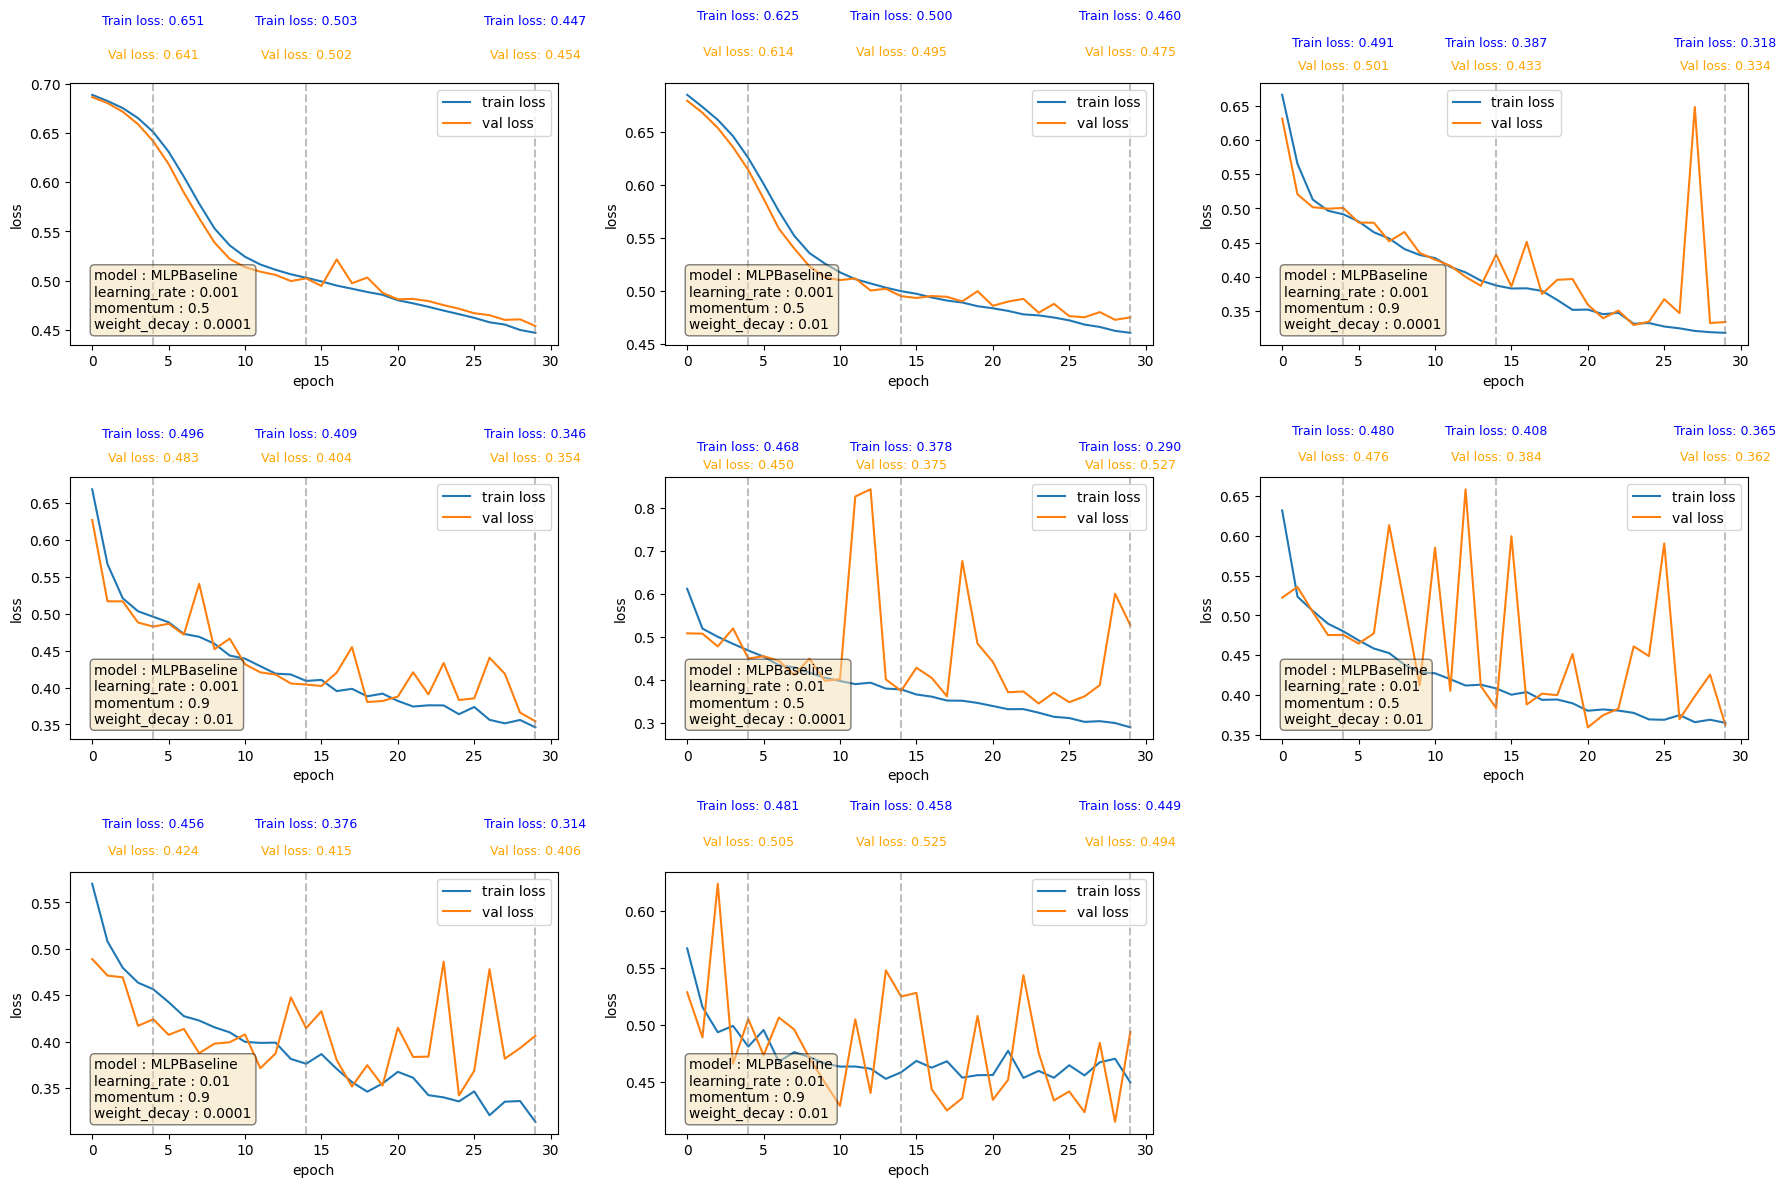

In [29]:
import math

runs = all_model_outcomes["MLPBaseline"]
n = len(runs)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))

# Flatten in case rows > 1
axes = axes.flatten() if n > 1 else [axes]

for ax, (params, train_losses, val_losses) in zip(axes, runs):
    plot_train_val_losses(
        train_losses=train_losses,
        val_losses=val_losses,
        params=params,
        ax=ax,
    )

# Remove unused axes
for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


In [24]:
# TODO: confusion matrix on performance